In [1]:
import opendssdirect as dss
import os
print(dss.__version__)
import numpy as np
import matplotlib.pyplot as plt

0.9.4


In [9]:
t = np.arange(0.0, 0.04, 0.0002)
w = 2*np.pi*50 # f = 50
rotation_unit = np.exp(1j*w*t)

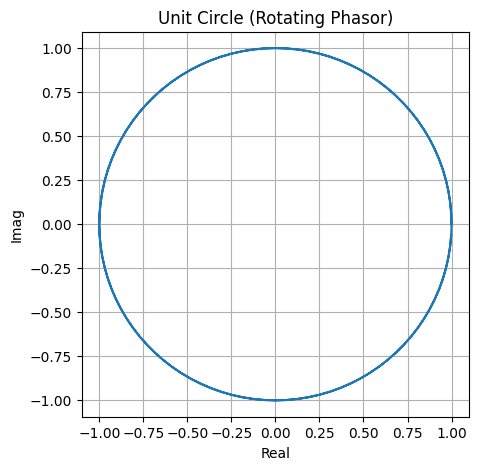

In [11]:
plt.figure(figsize=(5,5))
plt.plot(rotation_unit.real, rotation_unit.imag)
plt.xlabel("Real")
plt.ylabel("Imag")
plt.title("Unit Circle (Rotating Phasor)")
plt.axis("equal")   # ensures the circle isn't distorted
plt.grid(True)
plt.show()

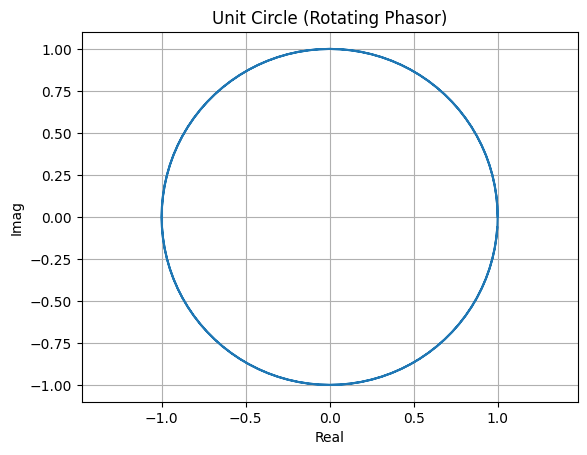

In [12]:
rotation_unit_2 = np.cos(w*t) + 1j*np.sin(w*t)
plt.plot(rotation_unit_2.real, rotation_unit_2.imag)
plt.xlabel("Real")
plt.ylabel("Imag")
plt.title("Unit Circle (Rotating Phasor)")
plt.axis("equal")   # ensures the circle isn't distorted
plt.grid(True)
plt.show()

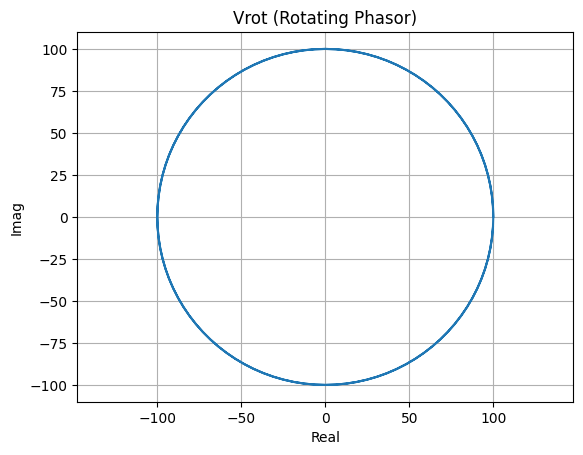

In [13]:
V = 100 * np.exp(0)
I = 50 * np.exp(1j * 30*np.pi/180)
Vrot = V * rotation_unit
Irot = I * rotation_unit

plt.plot(Vrot.real, Vrot.imag)
plt.xlabel("Real")
plt.ylabel("Imag")
plt.title("Vrot (Rotating Phasor)")
plt.axis("equal")   # ensures the circle isn't distorted
plt.grid(True)
plt.show()

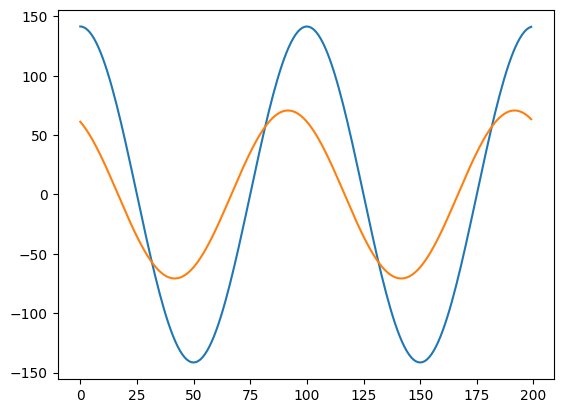

In [17]:
plt.plot(np.sqrt(2)*Vrot.real)
plt.plot(np.sqrt(2)*Irot.real)
plt.show()

In [23]:
phase = np.arctan2(20, 150)
degree = np.degrees(phase)
mag = np.sqrt(150**2 + 20**2)
mag, degree

(np.float64(151.32745950421557), np.float64(7.594643368591445))

In [24]:
150 * np.exp(1j * 30*np.pi/180)

np.complex128(129.9038105676658+74.99999999999999j)

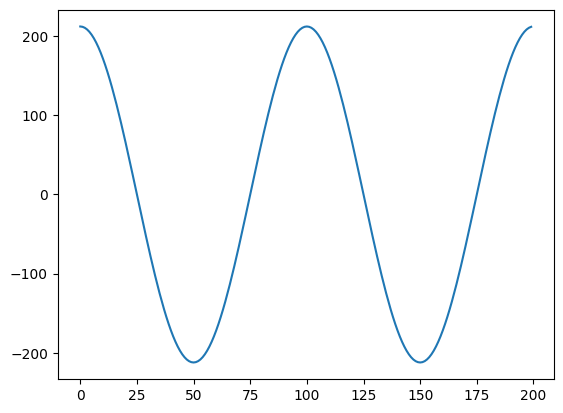

In [ ]:
V = 150 # RMS
I = 2 # RMS 

# R = 75
# 300 W real power I^2 R = 300 
# Apparent power = IV = 300
f = 50
w = 2*np.pi*f
t = np.arange(0.0, 0.04, 0.0002)

unit = np.exp(1j * (w*t))
# plt.plot(unit.real);

Vwave = V * np.sqrt(2) * unit
plt.plot(Vwave.real);


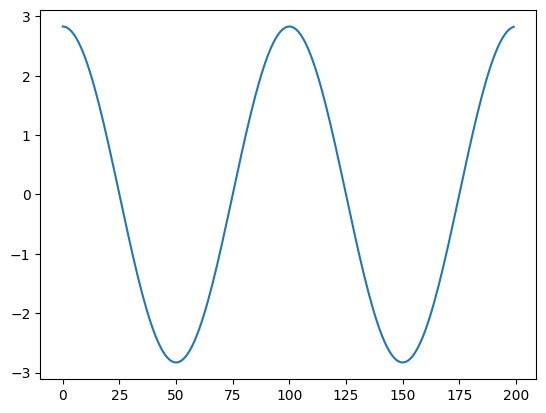

In [33]:
Iwave = I * np.sqrt(2) * unit
plt.plot(Iwave.real);

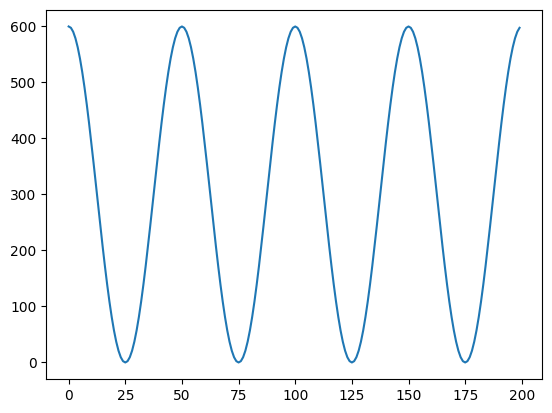

In [ ]:
# instaneous power
Pinst = Iwave.real * Vwave.real
plt.plot(Pinst); # always positive

In [ ]:
P = I**2 * 75 # R=75
P # real power, which is the mean of instanenous power wave 

300

In [ ]:
# Inductance 
# The larger the inductance, the smaller the current
L = 200 * 1e-6  # 200 mu H
R = 0

V = 200  # rms
w = 2 * np.pi * 50
XL = 1j * w * L    # Reactance 
Z = R + XL

I = V / Z
Imag = abs(I)
Iphase = np.angle(I, deg=True)  # -90
Imag, Iphase

(3183.0988618379074, np.float64(-90.0))

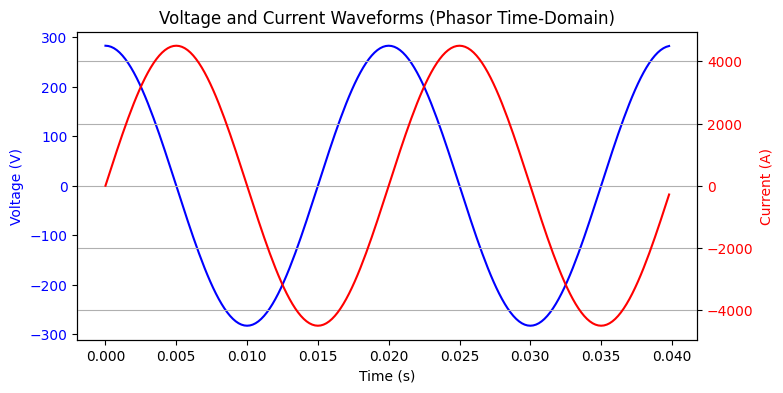

In [ ]:
t = np.arange(0.0, 0.04, 0.0002)
unit = np.exp(1j * (w*t))

Vphasor = unit * V
Iphasor = unit * I

fig, ax1 = plt.subplots(figsize=(8,4))

# Left axis: voltage
ax1.plot(t, Vphasor.real * np.sqrt(2), 'b', label='Voltage')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Voltage (V)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Right axis: current
# See the 90° lag for inductors
ax2 = ax1.twinx()
ax2.plot(t, Iphasor.real * np.sqrt(2), 'r', label='Current')
ax2.set_ylabel('Current (A)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Voltage and Current Waveforms (Phasor Time-Domain)')
plt.grid(True)
plt.show()

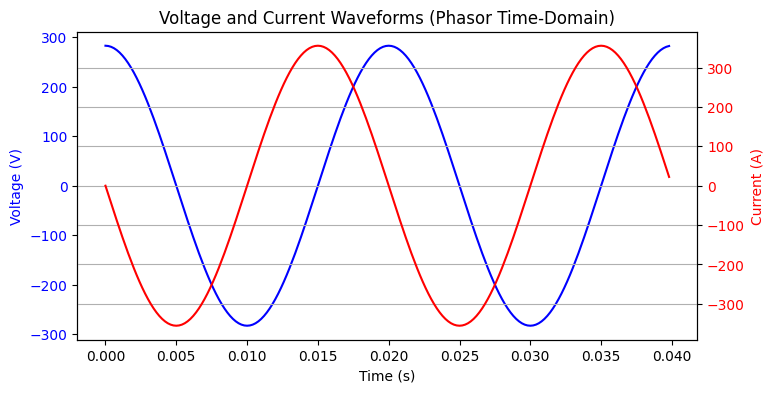

In [ ]:
# Capacitance 
# The larger the capacitance, the larger the current
C = 2000 * 1e-6  # 2000 mu F
R = 0

V = 200  # rms
w = 2 * np.pi * 50
XC = 1 / (1j * w * C )
Z = R + XC

I = V / Z
Imag = abs(I)
Iphase = np.angle(I, deg=True)  # -90
Imag, Iphase

# ---------- plot v and I waveforms --------------
t = np.arange(0.0, 0.04, 0.0002)
unit = np.exp(1j * (w*t))

Vphasor = unit * V
Iphasor = unit * I

fig, ax1 = plt.subplots(figsize=(8,4))

# Left axis: voltage
ax1.plot(t, Vphasor.real * np.sqrt(2), 'b', label='Voltage')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Voltage (V)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Right axis: current
# See the 90° lag for inductors
ax2 = ax1.twinx()
ax2.plot(t, Iphasor.real * np.sqrt(2), 'r', label='Current')
ax2.set_ylabel('Current (A)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Voltage and Current Waveforms (Phasor Time-Domain)')
plt.grid(True)
plt.show()

In [ ]:
# Only Inductance -> Positive reactance   XL = 1j * w * L 
# Only Capacitance -> Negative reactance  XC = 1 / (1j * w * C )
XL, XC

(0.06283185307179585j, -0.7957747154594768j)

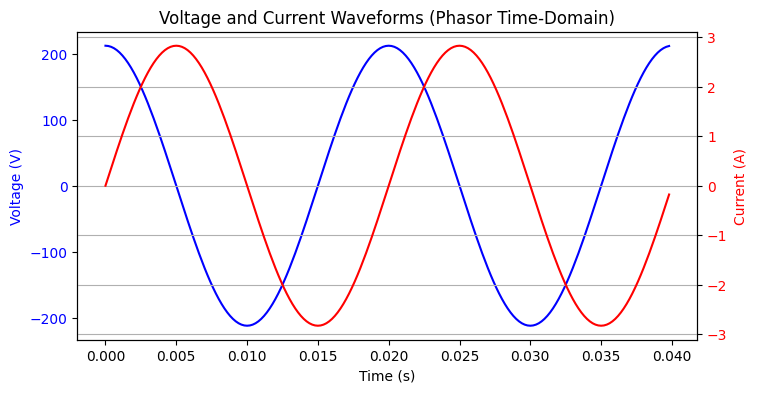

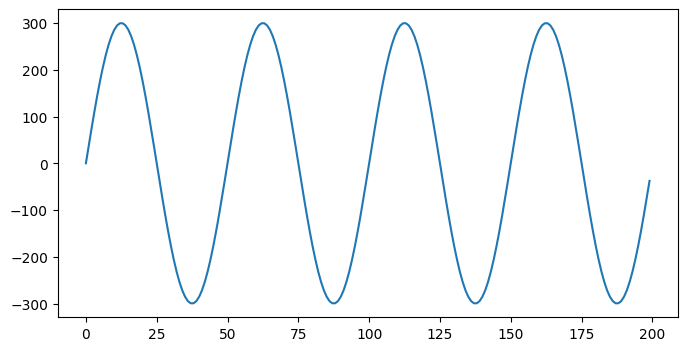

In [4]:
V = 150 # rms
I = 2

t = np.arange(0, 0.04, 0.0002)
w = 2 * np.pi * 50
unit = np.exp(1j * w * t)

Vwave = np.sqrt(2) * V * unit

Iwave = np.sqrt(2) * I * unit * np.exp(-1j *np.pi / 2) # lag in 90 degree

Pinst = Vwave.real * Iwave.real

fig, ax1 = plt.subplots(figsize=(8,4))

# Left axis: voltage
ax1.plot(t, Vwave, 'b', label='Voltage')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Voltage (V)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Right axis: current
# See the 90° lag for inductors
ax2 = ax1.twinx()
ax2.plot(t, Iwave, 'r', label='Current')
ax2.set_ylabel('Current (A)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Voltage and Current Waveforms (Phasor Time-Domain)')
plt.grid(True)
plt.show()

fig, ax1 = plt.subplots(figsize=(8,4))
plt.plot(Pinst)
plt.show()

In [ ]:
X = 75  # V = 150, I = 2
Q = I**2 * X  # reactive power 𝑄 = 𝑉_rms 𝐼_rms sin(𝜙) , and 𝜙 = 90 degree for pure inductance
Q 

300

In [ ]:
# A 10mF capacitor is installed in a shunt configuration at a 100 V load.
#  Calculate the reactive power generated by this capacitor if we assume the system operates at a 50 Hz frequency.
C = 10 * 1e-3 # F
V = 100
f = 50
w = 2 * np.pi * f
Xc = 1 / (1j * w * C)
I = V / Xc
P = V * I 
P

(-0+31415.926535897932j)

In [10]:
# A series inductor has an inductance of 10 mH. It carries a 50 Hz current of 4 + j3 A.
#  Calculate the reactive power absorbed by this inductor.
L = 10 * 1e-3 # H
I = 4 + 3j # A
Imag = np.sqrt(I.real**2 + I.imag**2)
f = 50
w = 2 * np.pi * f
XL = 1j * w * L
P = Imag**2 * XL 
P

np.complex128(78.53981633974483j)